In [1]:
import numpy as np
print(np.__version__)


import torch
print(torch.__version__)

import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

from tqdm.notebook import trange

import random
import math

1.26.4
2.6.0+cu118


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# import os 
# os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
# os.environ["CUDA_VISIBLE_DEVICES"]="0, 1"

In [3]:
class TwelveJanggi:
    def __init__(self):
        self.row_count = 4
        self.column_count = 3
        self.direction_count = 8
        self.type_count = 4
        # action space: (row, col, move direction or put type)
        self.action_size = 4 * 3 * ( 8 + 4 )
        self.drow = [-1, -1, 0, 1, 1, 1, 0, -1]
        self.dcol = [0, 1, 1, 1, 0, -1, -1, -1]
        self.e1 = np.array([[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]])
        self.e2 = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]])
        self.e3 = np.array([[0, 1], [1, 0]])
        
    def __repr__(self):
        return "TwelveJanggi"
        
    def get_initial_state(self):
        initial_state = np.zeros((4, 5))
        # 子 = 1, 將 = 2, 相 = 3, 王 = 4, 後 = 5
        initial_state[0][0] = -2
        initial_state[0][1] = -4
        initial_state[0][2] = -3
        initial_state[1][1] = -1
        initial_state[2][1] = 1
        initial_state[3][0] = 3
        initial_state[3][1] = 4
        initial_state[3][2] = 2
        
        return initial_state
    
    def get_next_state(self, state, action, player):
        row = action[0]
        col = action[1]
        if action[2] < 8:
            if state[row + self.drow[action[2]]][col + self.dcol[action[2]]] < 0:
                if (-1) * state[row + self.drow[action[2]]][col + self.dcol[action[2]]] != 5:
                    state[int((-1) * state[row + self.drow[action[2]]][col + self.dcol[action[2]]]-1)][3] += 1
                else:
                    state[0][3] += 1
            state[row + self.drow[action[2]]][col + self.dcol[action[2]]] = state[row][col]
            if state[row + self.drow[action[2]]][col + self.dcol[action[2]]] == 1 and row + self.drow[action[2]] == 0:
                state[row + self.drow[action[2]]][col + self.dcol[action[2]]] = 5
            state[row][col] = 0
        else:
            state[action[2] - self.direction_count][3] -= 1;
            state[row][col] = action[2] - self.direction_count + 1
        return self.change_perspective(state, player)
    
    def restrict(self, row, col):
        return row >= 0 and row < self.row_count and col >= 0 and col < self.column_count
    
    def get_valid_moves(self, state):
        valid_action = np.ones(4 * 3 * (8 + 4))
        for row in range(4):
            for col in range(3):
                chosen = state[row][col]
                for move in range(8):
                    act = row * 36 + col * 12 + move
                    if chosen <= 0:
                        valid_action[act] = 0
                    else:
                        if not self.restrict(row+self.drow[move], col+self.dcol[move]):
                            valid_action[act] = 0
                        elif state[row+self.drow[move]][col+self.dcol[move]] > 0:
                            valid_action[act] = 0
                        else:
                            if chosen == 1:
                                if move != 0:
                                    valid_action[act] = 0
                            elif chosen == 2:
                                if move == 1 or move == 3 or move == 5 or move == 7:
                                    valid_action[act] = 0
                            elif chosen == 3:
                                if move == 0 or move == 2 or move == 4 or move == 6:
                                    valid_action[act] = 0
                            elif chosen == 5:
                                if move == 3 or move == 5:
                                    valid_action[act] = 0
                for put in range(4):
                    act = row * 36 + col * 12 + put + 8
                    if state[put][3] <= 0:
                        valid_action[act] = 0
                    else:
                        if chosen != 0:
                            valid_action[act] = 0
                        else:
                            if row == 0:
                                valid_action[act] = 0
        return valid_action
    
    def check_win(self, state, action):
        if action[2] >= 8:
            return False
        
        row = -1
        col = -1
        
        if state[3][3] > 0 or state[3][4] > 0:
            return True
        
        if state[3][0] == -4 or state[3][1] == -4 or state[3][2] == -4:
            if state[3][0] == -4:
                row = 3
                col = 0
            elif state[3][1] == -4:
                row = 3
                col = 1
            elif state[3][2] == -4:
                row = 3
                col = 2
            valid_action = self.get_valid_moves(state)
            for i in range(4):
                for j in range(3):
                    for k in range(8):
                        if valid_action[i * 36 + j * 12 + k] == 1 and i + self.drow[k] == row and j + self.dcol[k] == col:
                            return False
            return True
        
        flip_state = self.change_perspective(state, -1)
        if flip_state[3][0] == -4 or flip_state[3][1] == -4 or flip_state[3][2] == -4:
            if flip_state[3][0] == -4:
                row = 3
                col = 0
            elif flip_state[3][1] == -4:
                row = 3
                col = 1
            elif flip_state[3][2] == -4:
                row = 3
                col = 2
            valid_action = self.get_valid_moves(flip_state)
            for i in range(4):
                for j in range(3):
                    for k in range(8):
                        if valid_action[i * 36 + j * 12 + k] == 1 and i + self.drow[k] == row and j + self.dcol[k] == col:
                            return False
            return True
        
        return False
    
    def get_value_and_terminated(self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False
    
    def get_opponent(self, player):
        return -player
    
    def get_opponent_value(self, value):
        return -value
    
    def change_perspective(self, state, player):
        if player == -1:
            board = state[:, 0:3]
            captive = state[:, 3:]
            return np.concatenate((np.matmul(np.matmul(self.e1, board), self.e2)*(-1), np.matmul(captive, self.e3)), axis=1).astype(int)
        else:
            return state
    
    def get_encoded_state(self, state):
        encoded = np.zeros([19, 4, 3]).astype(np.float32)
        for i in range(-5, 6, 1):
            for row in range(4):
                for col in range(3):
                    if state[row][col] == i:
                        encoded[i+5, row, col] = 1
        for i in range(4):
            encoded[i+11, 1:, :] = state[i][3]
            encoded[i+15, 1:, :] = state[i][4]
        return encoded

In [12]:
game = TwelveJanggi()
player = 1

state = game.get_initial_state()


while True:
    print(state[:, 0:3])
    print("player captvie:", state[:, 3])
    print("opponent captive:", state[:, 4])
    valid_moves = game.get_valid_moves(state)
    valid_moves_list = []
    for i in range(len(valid_moves)):
        if valid_moves[i] == 1:
            valid_moves_list.append("{0}행 {1}열 {2}".format(i//36, (i%36)//12, i%12))
    print("valid_moves", valid_moves_list)
    action1 = int(input(f"{player}_1:"))
    action2 = int(input(f"{player}_2:"))
    action3 = int(input(f"{player}_3:"))
    action = np.array([action1, action2, action3])
    
    if valid_moves[action[0]*36+action[1]*12+action[2]] == 0:
        print("action not valid")
        continue
        
    state = game.get_next_state(state, action, player)
    
    value, is_terminal = game.get_value_and_terminated(state, action)
    
    if is_terminal:
        print(state)
        if value == 1:
            print(player, "won")
        else:
            print("draw")
        break
        
    player = game.get_opponent(player)
    state = game.change_perspective(state, player)

[[-2. -4. -3.]
 [ 0. -1.  0.]
 [ 0.  1.  0.]
 [ 3.  4.  2.]]
player captvie: [0. 0. 0. 0.]
opponent captive: [0. 0. 0. 0.]
valid_moves ['2행 1열 0', '3행 1열 1', '3행 1열 7', '3행 2열 0']


1_1: 2
1_2: 1
1_3: 0


[[-2 -4 -3]
 [ 0  0  0]
 [ 0 -1  0]
 [ 3  4  2]]
player captvie: [0 0 0 0]
opponent captive: [1 0 0 0]
valid_moves ['3행 0열 1', '3행 1열 0', '3행 1열 1', '3행 1열 7', '3행 2열 0']


-1_1: 3
-1_2: 0
-1_3: 1


[[-2 -4  0]
 [ 0 -3  0]
 [ 0  0  0]
 [ 3  4  2]]
player captvie: [1 0 0 0]
opponent captive: [1 0 0 0]
valid_moves ['1행 0열 8', '1행 2열 8', '2행 0열 8', '2행 1열 8', '2행 2열 8', '3행 0열 1', '3행 1열 0', '3행 1열 1', '3행 1열 7', '3행 2열 0']


1_1: 2
1_2: 1
1_3: 8


[[-2 -4 -3]
 [ 0 -1  0]
 [ 0  3  0]
 [ 0  4  2]]
player captvie: [1 0 0 0]
opponent captive: [0 0 0 0]
valid_moves ['1행 0열 8', '1행 2열 8', '2행 0열 8', '2행 1열 1', '2행 1열 5', '2행 1열 7', '2행 2열 8', '3행 0열 8', '3행 1열 1', '3행 1열 6', '3행 1열 7', '3행 2열 0']


KeyboardInterrupt: Interrupted by user

In [13]:
class ResNet(nn.Module):
    def __init__(self, game, num_resBlocks, num_hidden, device):
        super().__init__()
        
        self.device = device
        self.startBlock = nn.Sequential(
            nn.Conv2d(19, num_hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )
        
        self.backBone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_resBlocks)]
        )
        
        self.policyHead = nn.Sequential(
            nn.Conv2d(num_hidden, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * game.row_count * game.column_count, game.action_size)
        )
        
        self.valueHead = nn.Sequential(
            nn.Conv2d(num_hidden, 19, kernel_size=3, padding=1),
            nn.BatchNorm2d(19),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(19 * game.row_count * game.column_count, 1),
            nn.Tanh()
        )
        
        self.to(device)
        
    def forward(self, x):
        x = self.startBlock(x)
        for resBlock in self.backBone:
            x = resBlock(x)
        policy = self.policyHead(x)
        value = self.valueHead(x)
        return policy, value
        
        
class ResBlock(nn.Module):
    def __init__(self, num_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)
        
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x
        

-0.0258942823857069
[[-2. -4. -3.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 3.  4.  2.  0.  0.]]
tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 1., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 1.],
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[1., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 1., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [1., 0., 1.],
          [1., 0., 1.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 1., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 1.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          [1., 0., 0.]],

     

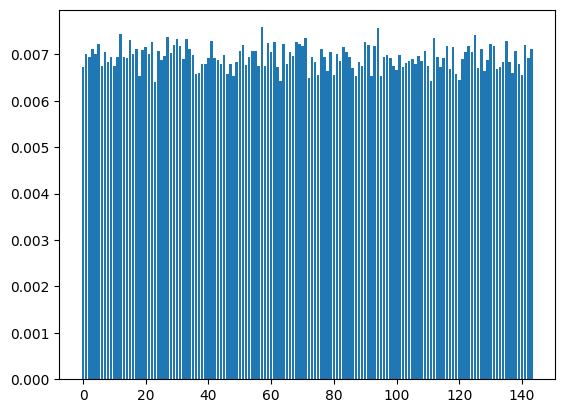

In [15]:
import matplotlib.pyplot as plt

game = TwelveJanggi()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

state = game.get_initial_state()

encoded_state = game.get_encoded_state(state)

tensor_state = torch.tensor(encoded_state, device=device).unsqueeze(0)

model = ResNet(game, 7, 256, device=device)
# model.load_state_dict(torch.load('model_1_TwelveJanggi_2.pt', map_location=device))
model.eval()

policy, value = model(tensor_state)
value = value.item()
policy = torch.softmax(policy, axis=1).squeeze(0).detach().cpu().numpy()

print(value)

print(state)
print(tensor_state)

plt.bar(range(game.action_size), policy)
plt.show()

In [6]:
class Node:
    def __init__(self, game, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        
        self.children = []
        
        self.visit_count = visit_count
        self.value_sum = 0
        
    def is_fully_expanded(self):
        return len(self.children) > 0
    
    def select(self):
        best_child = None
        best_ucb = -np.inf
        
        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb:
                best_child = child
                best_ucb = ucb
                
        return best_child
    
    def get_ucb(self, child):
        if child.visit_count == 0:
            q_value = 0
        else:
            q_value = 1 - ((child.value_sum / child.visit_count) + 1) / 2
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self, policy):
        for act, prob in enumerate(policy):
            action = np.array([act // 36, (act % 36) // 12, act % 12])
            if prob > 0:
                child_state = self.state.copy()
                child_state = self.game.get_next_state(child_state, action, 1)
                child_state = self.game.change_perspective(child_state, player=-1)

                child = Node(self.game, self.args, child_state, self, action, prob)
                self.children.append(child)
                
        return child
            
    def backpropagate(self, value):
        self.value_sum += value
        self.visit_count += 1
        
        value = self.game.get_opponent_value(value)
        if self.parent is not None:
            self.parent.backpropagate(value)  


class MCTS:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model
        
    @torch.no_grad()
    def search(self, state):
        root = Node(self.game, self.args, state, visit_count=1)
        
        policy, _ = self.model(
            torch.tensor(self.game.get_encoded_state(state), device=self.model.device).unsqueeze(0)
        )
        policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] \
            * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size)
        
        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)
        root.expand(policy)
        
        for search in range(self.args['num_searches']):
            node = root
            
            while node.is_fully_expanded():
                node = node.select()
                
            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
            value = self.game.get_opponent_value(value)
            
            if not is_terminal:
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(node.state), device=self.model.device).unsqueeze(0)
                )
                policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
                valid_moves = self.game.get_valid_moves(node.state)
                policy *= valid_moves
                policy /= np.sum(policy)
                
                value = value.item()
                
                node.expand(policy)
                
            node.backpropagate(value)
            
            
        action_probs = np.zeros(self.game.action_size)
        for child in root.children:
            action_probs[child.action_taken[0]*36+child.action_taken[1]*12+child.action_taken[2]] = child.visit_count
        action_probs /= np.sum(action_probs)
        return action_probs

In [7]:
class AlphaZero:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MCTS(game, args, model)
        
    def selfPlay(self):
        memory = []
        player = 1
        state = self.game.get_initial_state()
        
        while True:
            neutral_state = self.game.change_perspective(state, player)
            action_probs = self.mcts.search(neutral_state)
            
            memory.append((neutral_state, action_probs, player))
            
            temperature_action_probs = action_probs ** (1 / self.args['temperature'])
            act = np.random.choice(self.game.action_size, p=temperature_action_probs) # Divide temperature_action_probs with its sum in case of an error
            action = np.array([act // 36, (act % 36) // 12, act % 12])
            state = self.game.get_next_state(state, action, player)
            
            value, is_terminal = self.game.get_value_and_terminated(state, action)
            
            if is_terminal:
                returnMemory = []
                for hist_neutral_state, hist_action_probs, hist_player in memory:
                    hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                    returnMemory.append((
                        self.game.get_encoded_state(hist_neutral_state),
                        hist_action_probs,
                        hist_outcome
                    ))
                return returnMemory
            
            player = self.game.get_opponent(player)
                
    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])] # Change to memory[batchIdx:batchIdx+self.args['batch_size']] in case of an error
            state, policy_targets, value_targets = zip(*sample)
            
            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)
            
            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)
            
            out_policy, out_value = self.model(state)
            
            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
    
    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            
            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations']):
                memory += self.selfPlay()
                
            self.model.train()
            for epoch in trange(self.args['num_epochs']):
                self.train(memory)
            
            torch.save(self.model.state_dict(), f"model_{iteration}_{self.game}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}_{self.game}.pt")

In [8]:
class MCTSParallel:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model
        
    @torch.no_grad()
    def search(self, states, spGames):
        encoded = np.stack([self.game.get_encoded_state(st) for st in states])
        policy, _ = self.model(
            torch.tensor(encoded, device=self.model.device)
        )
        policy = torch.softmax(policy, axis=1).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] \
            * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size, size=policy.shape[0])
        
        for i, spg in enumerate(spGames):
            spg_policy = policy[i]
            valid_moves = self.game.get_valid_moves(states[i])
            spg_policy *= valid_moves
            spg_policy /= np.sum(spg_policy)

            spg.root = Node(self.game, self.args, states[i], visit_count=1)
            spg.root.expand(spg_policy)
        
        for search in range(self.args['num_searches']):
            for spg in spGames:
                spg.node = None
                node = spg.root

                while node.is_fully_expanded():
                    node = node.select()

                value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
                value = self.game.get_opponent_value(value)
                
                if is_terminal:
                    node.backpropagate(value)
                    
                else:
                    spg.node = node
                    
            expandable_spGames = [mappingIdx for mappingIdx in range(len(spGames)) if spGames[mappingIdx].node is not None]
                    
            if len(expandable_spGames) > 0:
                states = np.stack([spGames[mappingIdx].node.state for mappingIdx in expandable_spGames])
                
                encoded = np.stack([self.game.get_encoded_state(st) for st in states])
                policy, value = self.model(
                    torch.tensor(encoded, device=self.model.device)
                )
                policy = torch.softmax(policy, axis=1).cpu().numpy()
                value = value.cpu().numpy()
                
            for i, mappingIdx in enumerate(expandable_spGames):
                node = spGames[mappingIdx].node
                spg_policy, spg_value = policy[i], value[i]
                
                valid_moves = self.game.get_valid_moves(node.state)
                spg_policy *= valid_moves
                spg_policy /= np.sum(spg_policy)

                node.expand(spg_policy)
                node.backpropagate(spg_value)

In [9]:
import ray
class AlphaZeroParallel:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MCTSParallel(game, args, model)
    
    @ray.remote(num_gpus=0.05)
    def selfPlay(self):
        return_memory = []
        player = 1
        spGames = [SPG(self.game) for spg in range(self.args['num_parallel_games'])]
        game_count = 0
        
        while len(spGames) > 0:
            print(game_count)
            states = np.stack([spg.state for spg in spGames])
            neutral_states = np.stack([self.game.change_perspective(st, player) for st in states])
            self.mcts.search(neutral_states, spGames)
            
            for i in range(len(spGames))[::-1]:
                spg = spGames[i]
                
                action_probs = np.zeros(self.game.action_size)
                for child in spg.root.children:
                    action_probs[child.action_taken[0]*36+child.action_taken[1]*12+child.action_taken[2]] = child.visit_count
                action_probs /= np.sum(action_probs)

                spg.memory.append((spg.root.state, action_probs, player))

                temperature_action_probs = action_probs ** (1 / self.args['temperature'])
                temperature_action_probs /= np.sum(temperature_action_probs)
                act = np.random.choice(self.game.action_size, p=temperature_action_probs) # Divide temperature_action_probs with its sum in case of an error
                action = np.array([act // (game.column_count * (game.direction_count + game.type_count)), (act % (game.column_count * (game.direction_count + game.type_count))) // (game.direction_count + game.type_count), act % (game.direction_count + game.type_count)])

                spg.state = self.game.get_next_state(self.game.change_perspective(spg.state, player), action, player)
                spg.move_count += 1

                value, is_terminal = self.game.get_value_and_terminated(spg.state, action)
                
                if spg.move_count >= 100:
                    value = 0
                    is_terminal = True
                    
                if is_terminal:
                    for hist_neutral_state, hist_action_probs, hist_player in spg.memory:
                        hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                        return_memory.append((
                            self.game.get_encoded_state(hist_neutral_state),
                            hist_action_probs,
                            hist_outcome
                        ))
                    del spGames[i]
                    
            player = self.game.get_opponent(player)
            game_count += 1

        return return_memory
                
    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])] # Change to memory[batchIdx:batchIdx+self.args['batch_size']] in case of an error
            state, policy_targets, value_targets = zip(*sample)
            
            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)
            
            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)
            
            out_policy, out_value = self.model(state)
            
            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
    
    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            
            self.model.eval()
            
            futures = [self.selfPlay.remote(self) for i in range(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games'])]
            memory_list = ray.get(futures)
            for i in range(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games']):
                memory += memory_list[i]
                print(len(memory_list[i]))
            
            self.model.train()
            for epoch in trange(self.args['num_epochs']):
                self.train(memory)
            
            torch.save(self.model.state_dict(), f"model_{iteration+10}_{self.game}_6.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration+10}_{self.game}_6.pt")
            
class SPG:
    def __init__(self, game):
        self.state = game.get_initial_state()
        self.memory = []
        self.root = None
        self.node = None
        self.move_count = 0

In [56]:
import ray
import time

@ray.remote(num_gpus=0.1)
def squared(x):
    time.sleep(1)
    y = x**2
    return y

tic = time.perf_counter()

lazy_values = [squared.remote(x) for x in range(10)]
values = ray.get(lazy_values)

toc = time.perf_counter()

print(f'Elapsed time {toc - tic:.2f} s')
print(f'{values[:5]} ... {values[-5:]}')

ray.shutdown()


(selfPlay pid=138994) 7
(selfPlay pid=138994) 8
(selfPlay pid=138994) 9
(selfPlay pid=138994) 10


KeyboardInterrupt: 

In [ ]:
game = TwelveJanggi()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

model = ResNet(game, 7, 256, device)
model.load_state_dict(torch.load('model_9_TwelveJanggi_6.pt', map_location=device))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

args = {
    'C': 2,
    'num_searches': 300,
    'num_iterations': 20,
    'num_selfPlay_iterations': 20000,
    'num_parallel_games': 100,
    'num_epochs': 4,
    'batch_size': 32,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 1.75
}

alphaZero = AlphaZeroParallel(model, optimizer, game, args)
alphaZero.learn()

(selfPlay pid=1967429) 0
(selfPlay pid=1967429) 1 [repeated 20x across cluster]
(selfPlay pid=1967429) 2 [repeated 20x across cluster]
(selfPlay pid=1967450) 2 [repeated 19x across cluster]
(selfPlay pid=1967433) 3
(selfPlay pid=1967443) 3
(selfPlay pid=1967450) 3 [repeated 18x across cluster]
(selfPlay pid=1967443) 4
(selfPlay pid=1967469) 4
(selfPlay pid=1967445) 4 [repeated 16x across cluster]
(selfPlay pid=1967443) 5 [repeated 3x across cluster]
(selfPlay pid=1967437) 5 [repeated 15x across cluster]
(selfPlay pid=1967469) 6 [repeated 5x across cluster]
(selfPlay pid=1967440) 6 [repeated 14x across cluster]
(selfPlay pid=1967508) 6 [repeated 4x across cluster]
(selfPlay pid=1967469) 7 [repeated 2x across cluster]
(selfPlay pid=1967489) 7 [repeated 13x across cluster]
(selfPlay pid=1967526) 7 [repeated 3x across cluster]
(selfPlay pid=1967469) 8 [repeated 4x across cluster]
(selfPlay pid=1967489) 8 [repeated 12x across cluster]
(selfPlay pid=1967445) 8 [repeated 4x across cluster]
(s

  0%|          | 0/2 [00:00<?, ?it/s]

(selfPlay pid=1968505) 0
(selfPlay pid=1968877) 0 [repeated 15x across cluster]
(selfPlay pid=1968509) 1 [repeated 5x across cluster]
(selfPlay pid=1968509) 2 [repeated 20x across cluster]
(selfPlay pid=1968851) 2 [repeated 18x across cluster]
(selfPlay pid=1968509) 3 [repeated 2x across cluster]
(selfPlay pid=1968851) 3 [repeated 18x across cluster]
(selfPlay pid=1968511) 4 [repeated 2x across cluster]
(selfPlay pid=1968851) 4 [repeated 18x across cluster]
(selfPlay pid=1968511) 5 [repeated 2x across cluster]
(selfPlay pid=1968674) 5 [repeated 17x across cluster]
(selfPlay pid=1968877) 5 [repeated 2x across cluster]
(selfPlay pid=1968511) 6
(selfPlay pid=1968657) 6
(selfPlay pid=1968674) 6 [repeated 16x across cluster]
(selfPlay pid=1968877) 6 [repeated 2x across cluster]
(selfPlay pid=1968511) 7
(selfPlay pid=1968657) 7
(selfPlay pid=1968505) 7 [repeated 13x across cluster]
(selfPlay pid=1968877) 7 [repeated 5x across cluster]
(selfPlay pid=1968511) 8
(selfPlay pid=1968657) 8
(selfPl

In [21]:
game = TwelveJanggi()
player = 1

args = {
    'C': 2,
    'num_searches': 1000,
    'dirichlet_epsilon': 0.,
    'dirichlet_alpha': 0.3
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(game, 11, 128, device)
model.load_state_dict(torch.load("model_2_TwelveJanggi.pt", map_location=device))
model.eval()

mcts = MCTS(game, args, model)

state = game.get_initial_state()


while True:
    print(state[:, 0:3])
    
    if player == 1:
        valid_moves = game.get_valid_moves(state)
        print("valid_moves", valid_moves)
        action1 = int(input(f"{player}_1:"))
        action2 = int(input(f"{player}_2:"))
        action3 = int(input(f"{player}_3:"))
        action = np.array([action1, action2, action3])

        if valid_moves[action[0]*36+action[1]*12+action[2]] == 0:
            print("action not valid")
            continue
        
        state = game.get_next_state(state, action, player)
        
    else:
        state2 = state.copy()
        mcts_probs = mcts.search(state2)
        act = np.argmax(mcts_probs)
        action = np.array([act // 36, (act % 36) // 12, act % 12])
        
        state = game.get_next_state(state, action, player)
    
    value, is_terminal = game.get_value_and_terminated(state, action)
    
    if is_terminal:
        print(state[:, 0:3])
        if value == 1:
            print(player, "won")
        else:
            print("draw")
        break
        
    player = game.get_opponent(player)
    state = game.change_perspective(state, player)

[[-2. -4. -3.]
 [ 0. -1.  0.]
 [ 0.  1.  0.]
 [ 3.  4.  2.]]
valid_moves [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1_1:2
1_2:1
1_3:0
[[-2 -4 -3]
 [ 0  0  0]
 [ 0 -1  0]
 [ 3  4  2]]
[[-2  0 -3]
 [ 0 -4  0]
 [ 0  0  0]
 [ 3  4  2]]
valid_moves [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0

KeyboardInterrupt: Interrupted by user